# Seasonal / Monthly Mean Temperatures

This adds spring and fall mean temperatures to the dataset, at two resolutions each:

| column | meaning |
|---|---|
| `tmean_spring` | spring (Mar-May) mean temperature, deg C |
| `tmean_april` | April mean temperature, deg C |
| `tmean_fall` | fall (Sep-Nov) mean temperature, deg C |
| `tmean_october` | October mean temperature, deg C |

Daily mean temperature is `(TMAX + TMIN) / 2`; the seasonal/monthly value is the average of the daily means over that window (computed from the same GHCN station records the rest of `pa_data.csv` is built from).

April and October are singled out because they are the months where the last spring frost and first fall frost usually fall, so they are the most direct temperature analogues to the frost-timing responses.

The new columns live in a separate file, `data/pa_temps_supplement.csv`, keyed on `(station_id, year)`. It does not change `pa_data.csv`; you merge it in yourself with the cell below.

In [1]:
import pandas as pd
import matplotlib.pyplot as plt

pa = pd.read_csv("data/pa_data.csv")
temps = pd.read_csv("data/pa_temps_supplement.csv")

# Merge the new temperature columns onto the main table.
# how='left' keeps every row of pa_data; on=['station_id','year'] lines them up 1:1.
df = pa.merge(temps, on=["station_id", "year"], how="left")

print(df.shape)
df[["station_id", "year", "tmean_spring", "tmean_april", "tmean_fall", "tmean_october"]].head()

(10930, 71)


,station_id,year,tmean_spring,tmean_april,tmean_fall,tmean_october
0,USC00360022,2011,10.148333,10.916071,12.314286,11.000000
1,USC00360022,2012,13.512500,9.955000,12.115000,11.946774
2,USC00360022,2013,9.203846,10.683333,11.280220,12.712903
3,USC00360022,2014,8.120930,9.065000,10.852381,12.476667
4,USC00360022,2015,9.212222,10.750000,13.650610,11.162069


## Quick look at the new columns

Two checks worth doing before using these: (1) are they populated (they should be for ~99% of station-years), and (2) do they behave the way physical intuition says they should, i.e. warmer April should push the last spring frost earlier, and warmer October should push the first fall frost later.

In [2]:
cols = ["tmean_spring", "tmean_april", "tmean_fall", "tmean_october"]
df[cols].describe()

,tmean_spring,tmean_april,tmean_fall,tmean_october
count,10922.000000,10867.000000,10915.000000,10863.000000
mean,9.274904,9.399874,11.500793,11.458853
std,1.972032,2.185491,1.786418,2.183582
min,1.060563,1.823333,3.571429,1.291935
25%,7.949592,7.952500,10.318132,10.004839
50%,9.392663,9.486667,11.548901,11.506667
75%,10.640217,10.896667,12.701667,12.936290
max,15.725556,18.896552,18.908197,18.863333


corr(April temp, last spring frost)  = -0.508
corr(October temp, first fall frost) = 0.528


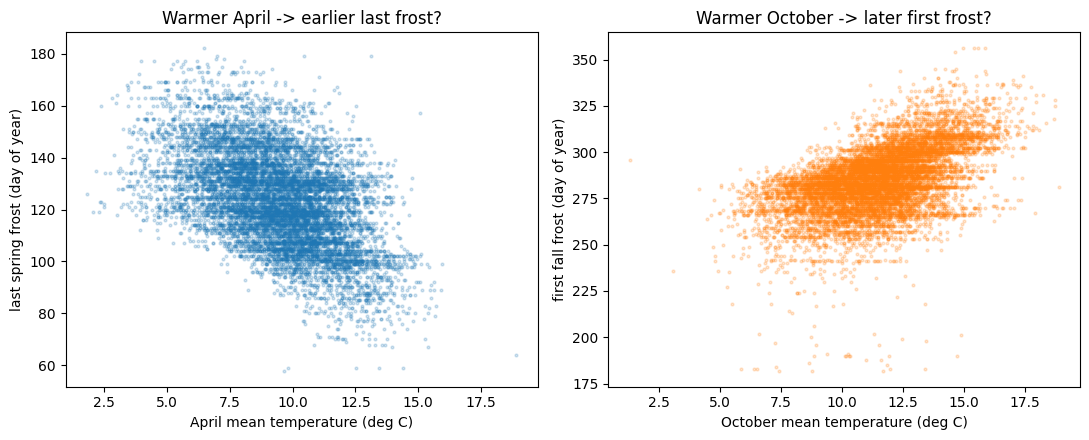

In [3]:
# April temperature vs last spring frost, and October temperature vs first fall frost.
fig, axes = plt.subplots(1, 2, figsize=(11, 4.5))

axes[0].scatter(df["tmean_april"], df["last_spring_frost_doy"], s=4, alpha=0.2)
axes[0].set_xlabel("April mean temperature (deg C)")
axes[0].set_ylabel("last spring frost (day of year)")
axes[0].set_title("Warmer April -> earlier last frost?")

axes[1].scatter(df["tmean_october"], df["first_fall_frost_doy"], s=4, alpha=0.2, color="C1")
axes[1].set_xlabel("October mean temperature (deg C)")
axes[1].set_ylabel("first fall frost (day of year)")
axes[1].set_title("Warmer October -> later first frost?")

# Correlations for reference
print("corr(April temp, last spring frost)  =",
      round(df["tmean_april"].corr(df["last_spring_frost_doy"]), 3))
print("corr(October temp, first fall frost) =",
      round(df["tmean_october"].corr(df["first_fall_frost_doy"]), 3))

plt.tight_layout()
plt.show()